# 1. Executive Summary 


# 2. Statement of the Problem
The objective of this program is to emperically analyze and validate the selected interpolation methods. These include the global interpolating polynomial $p_n(x)$, local piecewise interpolating polynomials $g_d(x)$, and cubic spline interpolation methods $s(x)$. The global interpolating polynomial is constructed using the Barycentric-1 form with Chebyshev points of the first kind to ensure convergence. The piecewise interpolating polynomial is formed using the local divided differnce form and supports the option for piecewise Hermite cubic interpolation. The interpolatory cubic spline is constructed using both the standard derivative parameterization and parameterization in terms of the cubic B-spline Basis. 

# 3. Description of the Mathematics

## 3.1 Interpolating Polynomial
The global interpolating polynomial consturcts a single polynomial $p_n(x) \in P_n$ satifying the conditions $$p_n(x) = f(x_i) \quad i = 1,...,n$$

This projects uses the Barycentric-1 form of the interpolating polynomial defined as 
$$p_n(x) =  w_{n+1}(x) \sum_{i=0}^n \frac{\gamma_i f(x_i)}{x-x_i} \quad  \text{where} \quad w_{n+1}(x) = \prod_{i=0}^n (x-x_i)$$

In this form, the weights are given by $$ \gamma_i = \frac{1}{\prod_{j \neq i}^n x_i - x_j}$$

Using this form, the weights can be precomputed for the polynomial evaluation, helping to imporve computational complexity and numerical stability associated with the method.

The Barycentric-1 form can be further improved upon by selecting chebyshev points for the mesh. This project uses the Chebyshev points of the first kind defined as 
$$x_i = cos(\frac{(2i+1)\pi}{2(n+1)}) \quad i = 0, ..., n $$

Using these points minimizes oscillatory behavior for the method, mitigates effects that arise from Runge's phenomenon, and ensures global convergence of the method by clustering near the endpoints of the interval. 

## 3.2 Piecewise Interpolating Polynomial 
To improve upon this design, the piecewise interpolating polynomial parititions the mesh  
$$a = x_0 \leq x_1 \leq ... \leq x_{n-1} \leq x_n = b$$ 

such that each piecewise polynomial $g_d(x)$ of degree $d$ is constructed on the subintervals $[x_i, x_{i+1}]$ using Newton's divided differences. The interpolating polynomal then takes the form 
$$g_d(x) = c_0 + c_1(x-x_0) + ... + c_d(x-x_0)...(x-x_{d-1})$$ 

where the coefficients $c_i$ are computed using the divided differences. 

Using this approach improves the stability of the global interpolating polynomial but has the draw back that the constructed polynomal is not garuanteed to be continously differentiale across the subinterval boundries.

## 3.3 Piecewise Cubic Hermite Interpolating Polynomial 
The cubic Hermite interpolant further enhances upon this by incorporating information about the function values and derivatives at the endpoints of each interval $[x_i, x_{i+1}]$ such that 
$$p_n(x_i) = f(x_i), \quad p_n(x_{i+1}) = f(x_{i+1}), \quad p'_n(x_i) = f'(x_i), \quad p'_n(x_{i+1}) = f'(x_{i+1}) $$

This ensures that each interpolating cubic polynomial on the subinterval is $C^1$ continous. Implying that both the function and its first derivative are continous across the interval. 

## 3.4 Interpolatory Cubic Spline
The interpolatory cubic spline constucts a piecewise cubic function $s(x)$ on each subinterval $[x_i,x_{i+1}]$ such that $s(x_i) = f(x_i)$ and $s'(x), s''(x)$ are continous at all nodes. 

The spline can then be determined by solving a tridiagonal linear system derived from the smoothness conditions specified by the boundary conditions. For this project, both the first derivative conditions $s'(x_0), s'(x_n)$ and the second derivative conditions $s''(x_0), s''(x_n)$ are supported.

Construction of the function using this form ensures that the spline is $C^2$ continous.

## 3.5 Interpolatory Cubic B-Spline
The cubic spline can also be parameterized by using the B-spline basis. In this form, the spline takes the form 
$$s(x) = \sum_{i=1}^n c_i B_i(x) $$

where $B_i(x)$ is the B-spline basis function and $c_i$ are the associated coefficients determined by the enforced interpolation conditions and boundary constraints.  

Using a uniform mesh with spacing $h = x_{i+1} - x_{i}$ the B-spline basis function $B_i(x)$ is defined as 
$$
B_i(x) =
\begin{cases}
\frac{1}{h^3}(x-x_{i-2})^3 & \text{if } x_{i-2} \leq x \leq x_{i-1} \\
\frac{1}{h^3}[(x-x_{i-2})^3 - 3(x - x_{i-1})^3] & \text{if } x_{i-1} \leq x \leq x_{i} \\
\frac{1}{h^3}[(x_{i+2}-x)^3 - 3(x_{i+1} - x)^3] & \text{if } x_{i} \leq x \leq x_{i+1} \\
\frac{1}{h^3}(x_{i+2}-x)^3  & \text{if } x_{i+1} \leq x \leq x_{i+2} \\
0 & \text{otherwise} 
\end{cases}
$$

Each basis function is nonzero inside the interval $[x_{i-2},x_{i+2 }]$ leading to compact support, improved numerical stability, and local control of the interpolant. This representation is equivilant to the cubic spline mathematically but with enhanced computational efficiency. 

# 4. Implementation of the Algorithms

### Necessary Libraries  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 4.1 Interpolating Polynomial 

### 4.1(a) Global Mesh Generation  

In [2]:
def Chebyshev_Points(n, interval=(-1, 1)):
    a, b = interval

    # Generate Chebyshev points in [-1,1]
    mesh = np.zeros(n)
    for i in range(n):
        val = ((2 * i + 1) * np.pi) / (2 * n)
        mesh[i] = np.cos(val)

    # Map to [a, b]
    mesh = 0.5 * (a + b) + 0.5 * (b - a) * mesh

    # Leja ordering
    ordered_mesh = np.zeros(n)

    # Start with point of largest magnitude
    index = np.argmax(np.abs(mesh))
    ordered_mesh[0] = mesh[index]

    # remove largest point
    remaining = list(mesh)
    remaining.pop(index)

    for i in range(1, n):
        best_index = 0
        best_val = -1

        for j, candidate in enumerate(remaining):
            prod = np.prod([abs(candidate - ordered_mesh[k]) for k in range(i)])
            if prod > best_val:
                best_val = prod
                best_index = j

        ordered_mesh[i] = remaining[best_index]
        remaining.pop(best_index)

    return ordered_mesh 

### Barycentric-1 Coefficients

In [3]:
def Barycentric1_Coefficients(mesh):
    n = len(mesh)
    
    # storage for weights
    gamma = np.ones(n)

    # Compute the weights
    for i in range(n):
        for j in range(n): 
            if i != j: 
                gamma[i] *= (mesh[i] - mesh[j])
                
    gamma = 1 / gamma
    
    return gamma

### Barycentric-1 Interpolation

In [4]:
def Barycentric1_Interpolation(eval_pts, mesh, gamma, fx): 
    n = len(eval_pts)

    # storage for polynomial 
    px = np.zeros(n)

    # polynomial construction
    for i in range(n): 
        x_curr = eval_pts[i]
        diff = x_curr - mesh 

        # check for spots that could be 0
        if np.any(diff == 0):
            # find the first index where diff = 0 
            j = np.where(diff == 0)[0][0]
            px[i] = fx[j]
            continue 
        
        lx = np.prod(diff)
        total = np.sum((gamma * fx) / diff)
        px[i] = lx * total
        
    return px 

## 4.2 Piecewise Interpolating Polynomial

### Local Mesh Generation

In [5]:
# partition global mesh into n subintervals
def Mesh_Partition(a, b, n): 
    return np.linspace(a, b, n+1)

# Define node distribution within subinterval 
def local_nodes(a_i, b_i, s, method): 
    if method == "uniform": 
        return np.linspace(a_i, b_i, s+1)
        
    if method == "chebyshev": 
        local_mesh = np.zeros(s+1)
        for i in range(s+1):
            val = (np.pi * i) / s 
            local_mesh[i] = np.cos(val)
        
        # Map to [a, b]
        mesh = 0.5 * (a_i + b_i) + 0.5 * (b_i - a_i) * local_mesh
        
        # Leja ordering
        ordered_mesh = np.zeros(s+1)

        # Start with point of largest magnitude
        index = np.argmax(np.abs(mesh))
        ordered_mesh[0] = mesh[index]

        # remove largest point
        remaining = list(mesh)
        remaining.pop(index)

        for i in range(1, s+1):
            best_index = 0
            best_val = -1

            for j, candidate in enumerate(remaining):
                prod = np.prod([abs(candidate - ordered_mesh[k]) for k in range(i)])
                if prod > best_val:
                    best_val = prod
                    best_index = j

            ordered_mesh[i] = remaining[best_index]
            remaining.pop(best_index)

        return ordered_mesh

### Divided Differences Coefficients

In [6]:
def divided_differences(x, y): 
    n = len(x)
    coef = y.copy()
    
    for i in range(1,n): 
        for j in range(n-1, i-1, -1): 
            coef[j] = (coef[j] - coef[j-1]) / (x[j] - x[j-i])

    return coef

### Local Newton Polynomial 

In [7]:
def Newton_Polynomial(local_ordered_nodes, coef, x): 
    n = len(coef)
    px = coef[-1]
    
    for i in range(n-2,-1,-1): 
        px = px * (x - local_ordered_nodes[i]) + coef[i]
        
    return px 

### Build Piecewise Interpolant

In [8]:
def piecewise_interpolation(f, a, b, m, s, method, eval_pts): 
    partition = np.linspace(a, b, m+1)
    pieces = []
    
    for i in range(m): 
        a_i, b_i = partition[i], partition[i+1]
        
        x_nodes = local_nodes(a_i, b_i, s, method)
        y_nodes = f(x_nodes)
        
        coef = divided_differences(x_nodes, y_nodes)
        pieces.append((a_i, b_i, x_nodes, coef))

    result = np.zeros(len(eval_pts))
    
    for k, x in enumerate(eval_pts):
        for (a_i, b_i, x_nodes, coef) in pieces: 
            if a_i <= x <= b_i: 
                result[k] = Newton_Polynomial(x_nodes, coef, x)
                break 
    return result

## 4.3 Piecewise Cubic Hermite Interpolating Polynomial 

### Hermite Divided Differences

In [9]:
def Hermite_Divided_Differences(x, f, df):
    #Initialize storage
    X = np.zeros(4) 
    DDT = np.zeros((4,4))
    
    # Set repeated roots X = [a_i, a_i, b_i, b_i]
    X[0] = X[1] = x[0]
    X[2] = X[3] = x[1]
    
    # Set First Column of table as function values
    # [f(a_i), f(a_i), f(b_i), f(b_i)]
    DDT[0,0] = f(x[0])
    DDT[1,0] = f(x[0])
    DDT[2,0] = f(x[1])
    DDT[3,0] = f(x[1])
    
    # First Div. Diff.
    DDT[1,1] = df(x[0])
    DDT[3,1] = df(x[1])
    
    # Normal Div. Diff. 
    DDT[2,1] = (DDT[2,0] - DDT[1,0]) / (X[2] - X[1])
    
    # Higher order Div. Diff. 
    for j in range(2, 4): 
        for i in range(j, 4): 
            DDT[i, j] = (DDT[i,j-1] - DDT[i-1,j-1]) / (X[i] - X[i-j])

    # return nodes and coefficients
    return X, DDT.diagonal()

### Piecewise Hermite Interpolation

In [10]:
def hermite_piecewise_interpolation(f, df, a, b, m, eval_pts): 
    partition = np.linspace(a, b, m+1)
    pieces = []
    
    for i in range(m): 
        a_i, b_i = partition[i], partition[i+1]
        
        X, coef = Hermite_Divided_Differences([a_i, b_i], f, df)
        pieces.append((a_i, b_i, X, coef))

    result = np.zeros(len(eval_pts))
    for k, x in enumerate(eval_pts):
        for (a_i, b_i, x_nodes, coef) in pieces:
            if a_i <= x <= b_i:
                result[k] = Newton_Polynomial(x_nodes, coef, x)
                break
    return result

## 4.4 Interpolatory Cubic Spline

### Cubic Spline Parameterization 

In [11]:
def cubic_spline_param(x, y, bc_type, bc_vals): 
    n = len(x) - 1
    h = np.diff(x) # x_i+1 - x_i 

    delta = np.diff(y) / h
    size = n + 1
    # Create System of Equations
    A = np.zeros((size, size))
    b = np.zeros(size)

    for i in range(1,n): 
        A[i, i-1] = h[i]
        A[i, i] = 2 * (h[i-1] + h[i])
        A[i, i+1] = h[i-1]
        b[i] = 3 * (h[i] * delta[i-1] + h[i-1] * delta[i])

    bc_1, bc_2 = bc_vals[0], bc_vals[1]

    if bc_type == 's1': 
        A[0, 0] = 1
        A[n, n] = 1
        b[0] = bc_1
        b[n] = bc_2 

    elif bc_type == 's2': 
        A[0, 0] = 2 
        A[0, 1] = 1
        A[n, n] = 2 
        A[n, n-1] = 1 
        b[0] = 3 * delta[0] - (h[0] / 2) * bc_1
        b[n] = 3 * delta[n-1] + (h[n-1] / 2) * bc_2

    d = np.linalg.solve(A, b)
    return d

### Cubic Spline Evalution

In [12]:
def cubic_spline_eval(t, x, y, d):
    t = np.asarray(t)
    s_t = np.zeros(len(t))
    h = np.diff(x)

    for k, t_k in enumerate(t):
        i = len(x) - 2
        for j in range(len(x) - 1): 
            if x[j] <= t_k <= x[j+1]:
                i = j
                break 

        h_i = h[i]
        mu = (t_k - x[i]) / h_i

        phi_00 = 2 * mu**3 - 3 * mu**2 + 1
        phi_10 = mu**3 - 2 * mu**2 + mu
        phi_01 = -2 * mu**3 + 3 * mu**2 
        phi_11 = mu**3 - mu**2 

        s_t[k] = (phi_00*y[i]) + (phi_10*h_i*d[i]) + (phi_01*y[i+1]) + (phi_11*h_i*d[i+1])
    return s_t

## 4.5 Interpolatory Cubic B-Spline

### B-Spline Basis

In [13]:
def bspline_basis(t, xi, h):
    # define the 5 relevant mesh points
    xim2 = xi - 2*h
    xim1 = xi - h
    # xi is center
    xip1 = xi + h
    xip2 = xi + 2*h

    if xim2 <= t <= xim1:
        return (t - xim2)**3 / h**3

    elif xim1 < t <= xi:
        u = t - xim1
        return (h**3 + 3*h**2*u + 3*h*u**2 - 3*u**3) / h**3

    elif xi < t <= xip1:
        u = xip1 - t
        return (h**3 + 3*h**2*u + 3*h*u**2 - 3*u**3) / h**3

    elif xip1 < t <= xip2:
        return (xip2 - t)**3 / h**3

    else:
        return 0.0

### B-Spline Basis Derivatives |

In [14]:
def bspline_basis_deriv(t, xi, h):
    xim2 = xi - 2*h
    xim1 = xi - h
    xip1 = xi + h
    xip2 = xi + 2*h

    if xim2 <= t <= xim1:
        return 3*(t - xim2)**2 / h**3

    elif xim1 < t <= xi:
        u = t - xim1
        return (3*h**2 + 6*h*u - 9*u**2) / h**3

    elif xi < t <= xip1:
        u = xip1 - t
        return -(3*h**2 + 6*h*u - 9*u**2) / h**3

    elif xip1 < t <= xip2:
        return -3*(xip2 - t)**2 / h**3

    else:
        return 0.0

### B-Spline Parameters

In [15]:
def cubic_bspline_param(x, y, bc_type, bc_vals):
    n = len(x) - 1
    h = x[1] - x[0]  # uniform spacing

    # The basis functions are B_{-1}, B_0, ..., B_{n+1}
    # Total: n+3 basis functions, n+3 unknowns
    # Center reference points: x_{-1}=x0-h, x_0, x_1, ..., x_n, x_{n+1}=xn+h
    xi_centers = np.concatenate([[x[0] - h], x, [x[-1] + h]])

    size = n + 3  # number of basis functions = number of unknowns
    A = np.zeros((size, size))
    r = np.zeros(size)

    # --- Interior interpolation rows: s(x_j) = y_j for j = 0,...,n ---
    # Row index k=1,...,n+1 corresponds to interpolation at x[0],...,x[n]
    # At x[j], only B_{j-1}, B_j, B_{j+1} are nonzero with values 1, 4, 1
    # (from the table on slide 14)
    for j in range(n + 1):
        row = j + 1  # rows 1 to n+1
        col = j      # alpha_{j-1} is at column j (0-indexed: alpha_{-1}=col0)
        A[row, col]     = 1.0  # B_{j-1}(x_j)
        A[row, col + 1] = 4.0  # B_j(x_j)
        A[row, col + 2] = 1.0  # B_{j+1}(x_j)
        r[row] = y[j]

    bc_left, bc_right = bc_vals

    # --- Boundary condition rows ---
    if bc_type == 's1':
        # s'(x0) = bc_left, s'(xn) = bc_right
        # At x0: B'_{-1}(x0)=3/h, B'_0(x0)=0, B'_1(x0)=-3/h (slide 14 table)
        # So: (3/h)*alpha_{-1} + 0*alpha_0 + (-3/h)*alpha_1 = bc_left
        A[0, 0] = -3.0/h   # B'_{-1}(x0): center is x_{-1}=x0-h, eval at x0=xim2+2h -> use formula
        A[0, 1] =  0.0
        A[0, 2] =  3.0/h
        r[0] = bc_left

        # At xn: B'_n(xn)=0, B'_{n+1} uses slide 14 symmetry
        A[n+2, n]   = -3.0/h
        A[n+2, n+1] =  0.0
        A[n+2, n+2] =  3.0/h
        r[n+2] = bc_right

    elif bc_type == 's2':
        # s''(x0) = bc_left, s''(xn) = bc_right
        # From slide 14 table: B''_i(xi-1)=6/h^2, B''_i(xi)=-12/h^2, B''_i(xi+1)=6/h^2
        # At x0: B''_{-1}(x0)=6/h^2, B''_0(x0)=-12/h^2, B''_1(x0)=6/h^2
        A[0, 0] =  6.0/h**2
        A[0, 1] = -12.0/h**2
        A[0, 2] =  6.0/h**2
        r[0] = bc_left

        # At xn:
        A[n+2, n]   =  6.0/h**2
        A[n+2, n+1] = -12.0/h**2
        A[n+2, n+2] =  6.0/h**2
        r[n+2] = bc_right

    alpha = np.linalg.solve(A, r)
    return xi_centers, alpha

### B-Spline Evaluation

In [16]:
def cubic_bspline_eval(t_arr, x, xi_centers, alpha):
    t_arr = np.asarray(t_arr)
    h = x[1] - x[0]
    n = len(x) - 1
    s_t = np.zeros(len(t_arr))

    for k, tk in enumerate(t_arr):
        # Find subinterval: x[i] <= tk <= x[i+1]
        i = len(x) - 2
        for j in range(len(x) - 1):
            if x[j] <= tk <= x[j+1]:
                i = j
                break

        # Only B_{i-1}, B_i, B_{i+1}, B_{i+2} are nonzero here
        # These correspond to alpha indices i, i+1, i+2, i+3
        # (since alpha[0]=alpha_{-1}, alpha[1]=alpha_0, ..., alpha[j+1]=alpha_j)
        val = 0.0
        for idx in range(i, i + 4):
            val += alpha[idx] * bspline_basis(tk, xi_centers[idx], h)
        s_t[k] = val

    return s_t

# 5. Experimental Design and Results

## Error Function

In [17]:
def Error_Statistics(true_vals, approx_vals):
    # Ensure inputs are numpy arrays for vector operations
    true_vals = np.asarray(true_vals)
    approx_vals = np.asarray(approx_vals)
    
    # 1. Absolute Error
    abs_error = np.abs(true_vals - approx_vals)
    
    # 2. Infinity Norm (Max Error)
    inf_norm = np.max(abs_error)
    
    # 3. Mean Squared Error (MSE)
    mse = np.mean(abs_error**2)
    
    # 4. Relative Error (handling division by zero)
    # We use a small epsilon or mask for values where true_vals == 0
    relative_error = np.where(true_vals != 0, 
                              abs_error / np.abs(true_vals), 
                              abs_error)
    max_rel_error = np.max(relative_error)
    
    stats = {
        "Infinity Norm": inf_norm,
        "MSE": mse,
        "Max Relative Error": max_rel_error,
        "Mean Absolute Error": np.mean(abs_error)
    }
    
    return stats

## 5.1 Task1 - Basic Testing \& Validation

### Barycentric-1 Basic Test

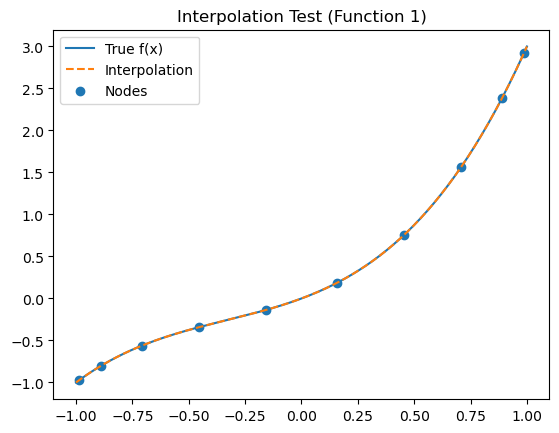

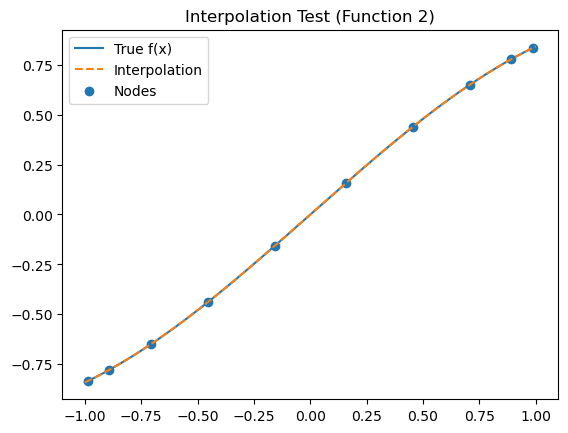

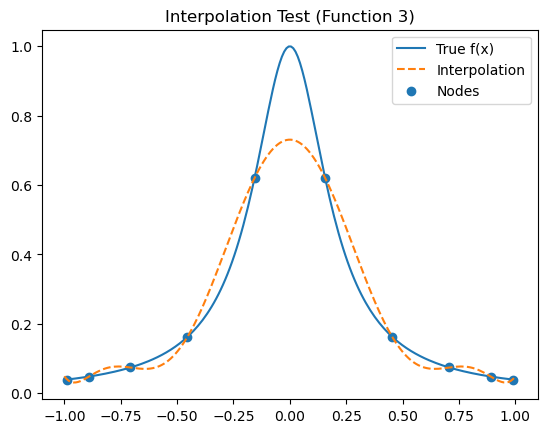

In [18]:
functions = [
    lambda x: x**3 + x**2 + x, # basic polynomial
    lambda x: np.sin(x),      # sin(x)
    lambda x: 1/(1 + 25*x**2) # Runge function
]

# True evaluation points for functions f(x) 
eval_pts = np.linspace(-1, 1, 200)

# Loop through functions
for idx, f in enumerate(functions):

    # Create mesh using chebyshev points
    mesh = Chebyshev_Points(10)
    # evaluate mesh for barycentric-1
    fx = f(mesh)
    # compute Barycentric weights
    gamma = Barycentric1_Coefficients(mesh)
    # Compute interpolating polynomial p(x) 
    px = Barycentric1_Interpolation(eval_pts, mesh, gamma, fx)
    # true f(x)
    true_vals = f(eval_pts)
    
    # Plotting True f(x) vs computed p(x)
    plt.figure()
    plt.plot(eval_pts, true_vals, label="True f(x)")
    plt.plot(eval_pts, px, '--', label="Interpolation")
    plt.scatter(mesh, fx, label="Nodes")
    plt.legend()
    plt.title(f"Interpolation Test (Function {idx+1})")
    plt.show()

### Piecewise Basic Tests

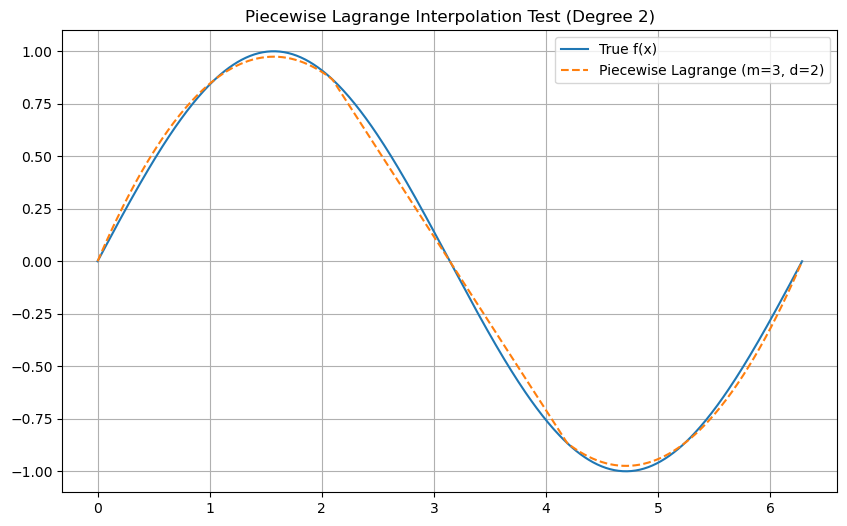

In [19]:
f = lambda x: np.sin(x) # function
a, b = 0, 2 * np.pi # Interval
m = 3 # subintervals
d = 2 # Degree of Polynomial

# Set evaluation points for true function
evaluation_pts = np.linspace(a, b, 500)
true_f = f(evaluation_pts)

# Build piecewise interpolation (method = 'uniform' or 'chebyshev')
pw_interpolation = piecewise_interpolation(f, a, b, m, d, method = "uniform", eval_pts = evaluation_pts)

# Plot 
plt.figure(figsize=(10, 6))
plt.plot(evaluation_pts, true_f, label='True f(x)')
plt.plot(evaluation_pts, pw_interpolation, '--', label=f'Piecewise Lagrange (m={m}, d={d})')
plt.title(f'Piecewise Lagrange Interpolation Test (Degree {d})')
plt.legend()
plt.grid(True)
plt.show()

### Piecewise Hermite Basic Tests

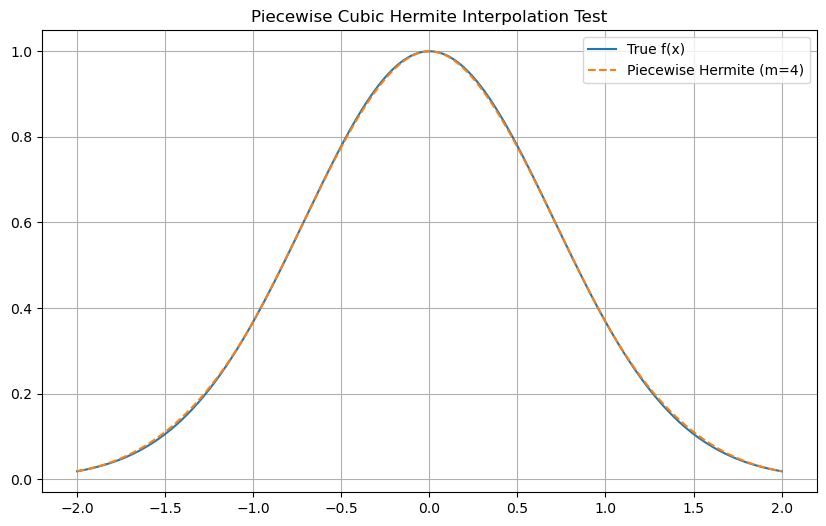

In [20]:
# 1. Define test function and its derivative
f = lambda x: np.exp(-x**2)
df = lambda x: -2 * x * np.exp(-x**2) # Derivative needed for Hermite
a, b = -2, 2
m = 4 # Number of subintervals
s = 3

# Set evaluation points for true function
evaluation_pts = np.linspace(a, b, 500)
true_f = f(evaluation_pts)

# Build piecewise interpolation (method = 'uniform' or 'chebyshev')
hermite_pw_interpolation = hermite_piecewise_interpolation(f, df, a, b, m, eval_pts=evaluation_pts)

#Plot
plt.figure(figsize=(10, 6))
plt.plot(evaluation_pts, true_f, label='True f(x)')
plt.plot(evaluation_pts, hermite_pw_interpolation, '--', label=f'Piecewise Hermite (m={m})')
plt.title('Piecewise Cubic Hermite Interpolation Test')
plt.legend()
plt.grid(True)
plt.show()

### Basic Spline Testing

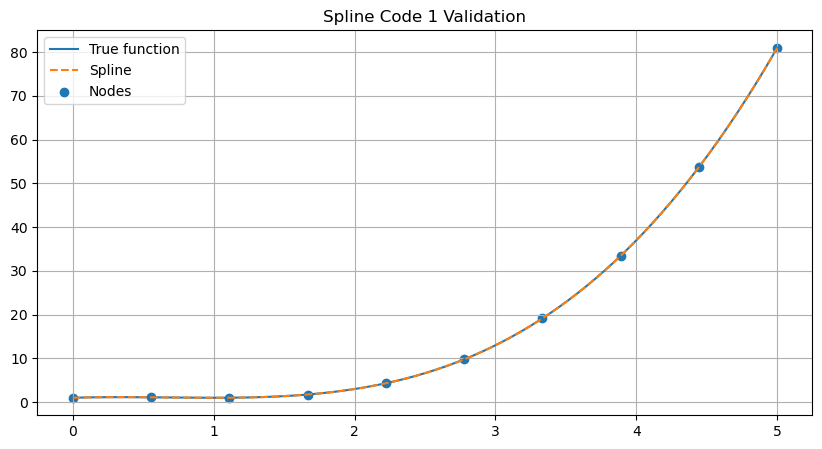

In [21]:
# Spline should reproduce any cubic polynomial exactly
f = lambda x: x**3 - 2*x**2 + x + 1
df = lambda x: 3*x**2 - 4*x + 1

x_mesh = np.linspace(0, 5, 10)
y_mesh = f(x_mesh)

# BC Type: 's1' or 's2'
params = cubic_spline_param(x_mesh, y_mesh, bc_type='s1', bc_vals=(df(x_mesh[0]), df(x_mesh[-1])))

eval_pts = np.linspace(0, 5, 300)
cubic_spline = cubic_spline_eval(eval_pts, x_mesh, y_mesh, params)
true_f = f(eval_pts)


plt.figure(figsize=(10, 5))
plt.plot(eval_pts, true_f, label='True function')
plt.plot(eval_pts, cubic_spline, '--', label='Spline')
plt.scatter(x_mesh, y_mesh, label='Nodes')
plt.legend()
plt.grid(True)
plt.title("Spline Code 1 Validation")
plt.show()

### B-Spline Basic Test

Max error (should be ~0): 7.105427357601002e-15


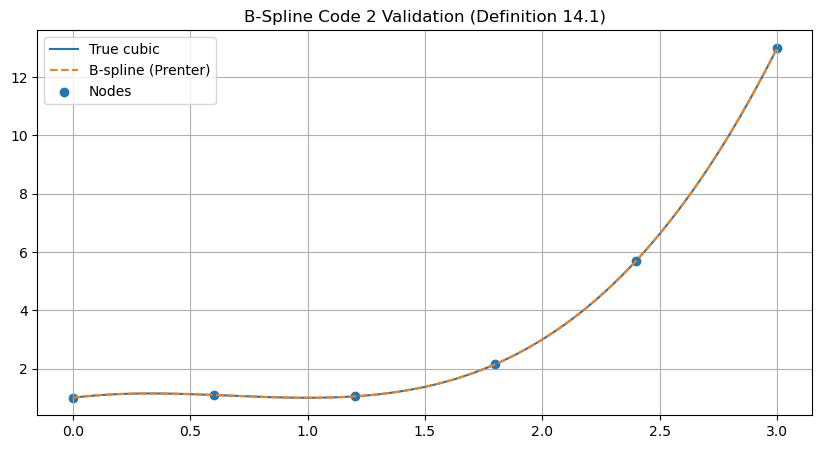

In [22]:
f  = lambda x: x**3 - 2*x**2 + x + 1
df = lambda x: 3*x**2 - 4*x + 1

x_mesh = np.linspace(0, 3, 6)
y_mesh = f(x_mesh)

xi_centers, alpha = cubic_bspline_param(x_mesh, y_mesh, bc_type='s1',
                                         bc_vals=(df(x_mesh[0]), df(x_mesh[-1])))

eval_pts  = np.linspace(0, 3, 300)
s_vals    = cubic_bspline_eval(eval_pts, x_mesh, xi_centers, alpha)
true_vals = f(eval_pts)

print("Max error (should be ~0):", np.max(np.abs(s_vals - true_vals)))

plt.figure(figsize=(10, 5))
plt.plot(eval_pts, true_vals, label='True cubic')
plt.plot(eval_pts, s_vals,   '--',  label='B-spline (Prenter)')
plt.scatter(x_mesh, y_mesh, label='Nodes')
plt.legend()
plt.grid(True)
plt.title("B-Spline Code 2 Validation (Definition 14.1)")
plt.show()

## 5.2 Task2 - Discrete Data Testing \& Validation 

# 6. Conclusion 